# Improved Baseline Models (CNN, RNN, LSTM) for Arabic Dialect Detection
This notebook implements the baseline models with several improvements for a research paper:
1. **AraBERT Tokenizer**: Uses Subword Tokenization to handle Arabic morphology and OOV words better than standard word-level tokenizers.
2. **Pre-trained Embeddings**: Extracts the actual word embedding weights from the AraBERT model to initialize the Keras Embedding layers, giving the baseline models a massive head start.
3. **Advanced Metrics**: Includes Matthews Correlation Coefficient (MCC) and ROC-AUC (One-vs-Rest) alongside F1 and Accuracy.



In [ ]:
%%capture
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn requests tensorflow


## 1. Imports & Setup


In [ ]:
import os
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Dense, Dropout, Bidirectional, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, matthews_corrcoef
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, AutoModel
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Data


In [ ]:
print("Fetching dataset...")
url = "https://raw.githubusercontent.com/JihadZa/IADD/main/IADD.json"
data = requests.get(url).json()
df = pd.DataFrame(data)

# Basic cleaning
df = df.dropna(subset=['Sentence'])
df['Sentence'] = df['Sentence'].astype(str).str.strip()
df = df[df['Sentence'].str.len() > 0].reset_index(drop=True)

print(f"Total samples: {len(df):,}")



Fetching dataset...
Total samples: 135,804


## 3. AraBERT Tokenizer & Pre-trained Embeddings
Instead of training Keras embeddings from scratch, we use the AraBERT tokenizer and its pre-trained embedding weights.


In [ ]:
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
print(f"Loading tokenizer and model: {MODEL_NAME}")

arabert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Load the TF version of AraBERT to easily grab its embedding matrix
arabert_model = AutoModel.from_pretrained(MODEL_NAME)

# Extract the embedding matrix
embedding_matrix = arabert_model.embeddings.word_embeddings.weight.detach().numpy()

VOCAB_SIZE = arabert_tokenizer.vocab_size
EMBEDDING_DIM = embedding_matrix.shape[1]
MAX_LEN_SEQ = 100

print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"Embedding Dimensions: {EMBEDDING_DIM}")
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")


Loading tokenizer and model: aubmindlab/bert-base-arabertv02


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vocabulary Size: 64000
Embedding Dimensions: 768
Embedding Matrix Shape: (64000, 768)


## 4. Tokenization Function
This uses the AraBERT tokenizer to convert text to integer sequences.


In [ ]:
def tokenize_for_keras(texts, tokenizer, max_len):
    # Generates a dictionary containing 'input_ids'
    encodings = tokenizer(
        texts.tolist(),
        truncation=True,
        padding=False,
        max_length=max_len
    )
    return encodings['input_ids']


## 5. Regional Classification Setup (6 Classes)


In [ ]:
# Label Encoding by REGION
label_list_k = sorted(df['Region'].unique())
label2id_k = {l: i for i, l in enumerate(label_list_k)}
id2label_k = {i: l for l, i in label2id_k.items()}
df['label_region'] = df['Region'].map(label2id_k)
NUM_LABELS_K = len(label_list_k)

# Train/Val/Test Split
train_df_k, temp_df_k = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df['label_region'])
val_df_k, test_df_k = train_test_split(temp_df_k, test_size=0.5, random_state=SEED, stratify=temp_df_k['label_region'])

# Tokenize
train_seqs_k = tokenize_for_keras(train_df_k['Sentence'], arabert_tokenizer, MAX_LEN_SEQ)
val_seqs_k   = tokenize_for_keras(val_df_k['Sentence'], arabert_tokenizer, MAX_LEN_SEQ)
test_seqs_k  = tokenize_for_keras(test_df_k['Sentence'], arabert_tokenizer, MAX_LEN_SEQ)

X_train_k = pad_sequences(train_seqs_k, maxlen=MAX_LEN_SEQ)
X_val_k   = pad_sequences(val_seqs_k, maxlen=MAX_LEN_SEQ)
X_test_k  = pad_sequences(test_seqs_k, maxlen=MAX_LEN_SEQ)

y_train_k = train_df_k['label_region'].values
y_val_k = val_df_k['label_region'].values
y_test_k = test_df_k['label_region'].values

# Class weights
w_k = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_k), y=y_train_k)
regional_class_weights = {i: w_k[i] for i in range(len(w_k))}

print(f"Setup complete for REGIONAL labels. Classes: {label_list_k}")


Setup complete for REGIONAL labels. Classes: ['EGY', 'GLF', 'IRQ', 'LEV', 'MGH', 'general']


## 6. Country Classification Setup (10 Classes)


In [ ]:
# Label Encoding for Countries
country_list = sorted(df['Country'].unique())
country2id = {l: i for i, l in enumerate(country_list)}
id2country = {i: (l if l != 'NA' else 'GULF') for l, i in country2id.items()}
display_country_list = [id2country[i] for i in range(len(id2country))]

df['label_country'] = df['Country'].map(country2id)
NUM_LABELS_C = len(country_list)

# Split
train_df_c, temp_df_c = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df['label_country'])
val_df_c, test_df_c = train_test_split(temp_df_c, test_size=0.5, random_state=SEED, stratify=temp_df_c['label_country'])

# Tokenize
train_seqs_c = tokenize_for_keras(train_df_c['Sentence'], arabert_tokenizer, MAX_LEN_SEQ)
val_seqs_c   = tokenize_for_keras(val_df_c['Sentence'], arabert_tokenizer, MAX_LEN_SEQ)
test_seqs_c  = tokenize_for_keras(test_df_c['Sentence'], arabert_tokenizer, MAX_LEN_SEQ)

# Pad
X_train_c = pad_sequences(train_seqs_c, maxlen=MAX_LEN_SEQ)
X_val_c   = pad_sequences(val_seqs_c, maxlen=MAX_LEN_SEQ)
X_test_c  = pad_sequences(test_seqs_c, maxlen=MAX_LEN_SEQ)


y_train_c = train_df_c['label_country'].values
y_val_c = val_df_c['label_country'].values
y_test_c = test_df_c['label_country'].values

# Class weights
w_c = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_c), y=y_train_c)
country_class_weights = {i: w_c[i] for i in range(len(w_c))}

print(f"Setup complete for COUNTRY labels. Display Labels: {display_country_list}")


Setup complete for COUNTRY labels. Display Labels: ['Algeria', 'Egypt', 'Iraq', 'Jordan', 'Lebanon', 'Morocco', 'GULF', 'Palestine', 'Syria', 'Tunisia']


## 7. Model Builders (Using Pre-trained AraBERT Embeddings)


In [ ]:
def build_keras_model(arch_type, num_labels):
    # Initialize Embedding layer with AraBERT weights
    # We set trainable=True to allow fine-tuning, but you can set to False to freeze them.
    embed_layer = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN_SEQ,
        trainable=False
    )

    if arch_type == 'rnn':
        model = Sequential([
            embed_layer,
            SimpleRNN(64, dropout=0.2),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(num_labels, activation='softmax')
        ])
    elif arch_type == 'lstm':
        model = Sequential([
            embed_layer,
            Bidirectional(LSTM(64, return_sequences=True)),
            Bidirectional(LSTM(32)),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(num_labels, activation='softmax')
        ])
    elif arch_type == 'cnn':
        model = Sequential([
            embed_layer,
            Conv1D(128, 5, activation='relu'),
            GlobalMaxPooling1D(),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(num_labels, activation='softmax')
        ])

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


## 8. Training Regional Models


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
EPOCHS = 15
BATCH_SIZE = 64

print("Initializing Regional Models...")
rnn_regional = build_keras_model('rnn', NUM_LABELS_K)
lstm_regional = build_keras_model('lstm', NUM_LABELS_K)
cnn_regional = build_keras_model('cnn', NUM_LABELS_K)

print("\n--- Training Regional Simple RNN ---")
rnn_regional.fit(X_train_k, y_train_k, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val_k, y_val_k), class_weight=regional_class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)
print("\n--- Training Regional Bi-LSTM ---")
lstm_regional.fit(X_train_k, y_train_k, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val_k, y_val_k), class_weight=regional_class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)
print("\n--- Training Regional CNN ---")
cnn_regional.fit(X_train_k, y_train_k, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val_k, y_val_k), class_weight=regional_class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)

Initializing Regional Models...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



--- Training Regional Simple RNN ---
Epoch 1/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.3223 - loss: 1.7233 - val_accuracy: 0.2445 - val_loss: 1.7261
Epoch 2/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3348 - loss: 1.6321 - val_accuracy: 0.4581 - val_loss: 1.5761
Epoch 3/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3975 - loss: 1.5356 - val_accuracy: 0.5414 - val_loss: 1.2887
Epoch 4/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4718 - loss: 1.4326 - val_accuracy: 0.4335 - val_loss: 1.5020
Epoch 5/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5074 - loss: 1.3306 - val_accuracy: 0.4986 - val_loss: 1.3108
Epoch 6/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5263 - loss: 1.2515 - val_accuracy: 0.5791 - val_loss: 1.0763
Epoch 7/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5475 - loss: 1.2185 - val_accuracy: 0.6297 - val_loss: 1.0139
Epoch 8/15
1486/1486 ━━━━━━━━━━━━━━━━━

## 9. Training Country Models


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
EPOCHS = 15
BATCH_SIZE = 64

print("Initializing Country Models...")
rnn_country = build_keras_model('rnn', NUM_LABELS_C)
lstm_country = build_keras_model('lstm', NUM_LABELS_C)
cnn_country = build_keras_model('cnn', NUM_LABELS_C)

print("\n--- Training Country Simple RNN ---")
rnn_country.fit(X_train_c, y_train_c, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val_c, y_val_c), class_weight=country_class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)
print("\n--- Training Country Bi-LSTM ---")
lstm_country.fit(X_train_c, y_train_c, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val_c, y_val_c), class_weight=country_class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)
print("\n--- Training Country CNN ---")
cnn_country.fit(X_train_c, y_train_c, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val_c, y_val_c), class_weight=country_class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)


Initializing Country Models...

--- Training Country Simple RNN ---
Epoch 1/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.2397 - loss: 1.9630 - val_accuracy: 0.3681 - val_loss: 1.6725
Epoch 2/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3155 - loss: 1.6340 - val_accuracy: 0.4213 - val_loss: 1.5048
Epoch 3/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3443 - loss: 1.5049 - val_accuracy: 0.4229 - val_loss: 1.4406
Epoch 4/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3457 - loss: 1.4644 - val_accuracy: 0.3522 - val_loss: 1.5361
Epoch 5/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3624 - loss: 1.3785 - val_accuracy: 0.4304 - val_loss: 1.4143
Epoch 6/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3681 - loss: 1.3384 - val_accuracy: 0.3730 - val_loss: 1.6231
Epoch 7/15
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.3625 - loss: 1.3592 - val_accuracy: 0.4109 - val_loss: 1.4129
Epoch 8/

## 10. Advanced Evaluation & Metrics
Includes Precision, Recall, F1, MCC, Confusion Matrices, and ROC-AUC Curves.


In [ ]:
def evaluate_advanced_metrics(model, X_test, y_test, labels, title):
    print(f"\n{'='*20} Advanced Evaluation: {title} {'='*20}")

    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Standard metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Weighted: {f1:.4f}")
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=labels))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Plot ROC-AUC (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=range(len(labels)))
    n_classes = len(labels)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        # We need to make sure y_test_bin has correct shape if only 2 classes,
        # but here we have 6 or 10 so it's safe to index [:, i]
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC {labels[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-class ROC Curve (One-vs-Rest) - {title}')
    plt.legend(loc="lower right")
    plt.show()

    return {'Model': title, 'Accuracy': acc, 'F1-Weighted': f1, 'MCC': mcc}




==================== Advanced Evaluation: Regional Simple RNN ====================
637/637 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Accuracy: 0.6243
F1-Weighted: 0.6831
Matthews Correlation Coefficient (MCC): 0.4690

Classification Report:
              precision    recall  f1-score   support

         EGY       0.14      0.75      0.24       726
         GLF       0.01      0.00      0.00      1002
         IRQ       0.06      0.24      0.10        33
         LEV       0.95      0.61      0.74     13136
         MGH       0.76      0.79      0.78      5099
     general       0.06      0.41      0.10       375

    accuracy                           0.62     20371
   macro avg       0.33      0.47      0.33     20371
weighted avg       0.81      0.62      0.68     20371



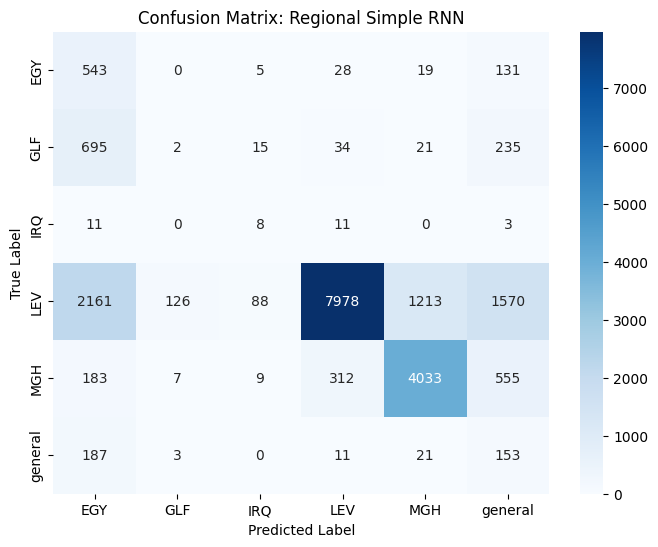

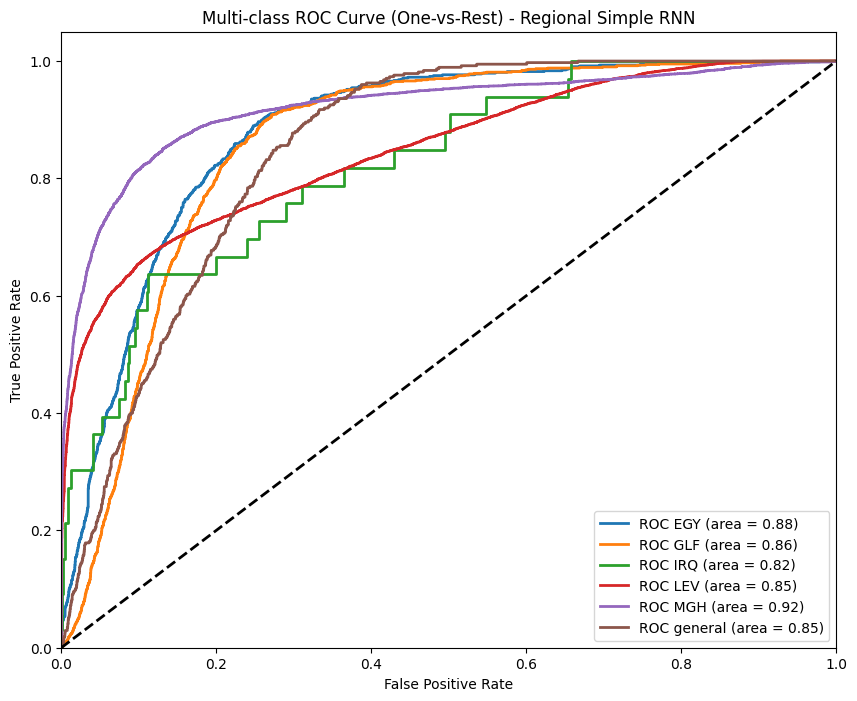


==================== Advanced Evaluation: Regional Bi-LSTM ====================
637/637 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
Accuracy: 0.7901
F1-Weighted: 0.8264
Matthews Correlation Coefficient (MCC): 0.6700

Classification Report:
              precision    recall  f1-score   support

         EGY       0.54      0.75      0.63       726
         GLF       0.53      0.71      0.61      1002
         IRQ       0.11      0.82      0.19        33
         LEV       0.98      0.77      0.86     13136
         MGH       0.84      0.89      0.86      5099
     general       0.10      0.53      0.16       375

    accuracy                           0.79     20371
   macro avg       0.52      0.74      0.55     20371
weighted avg       0.89      0.79      0.83     20371



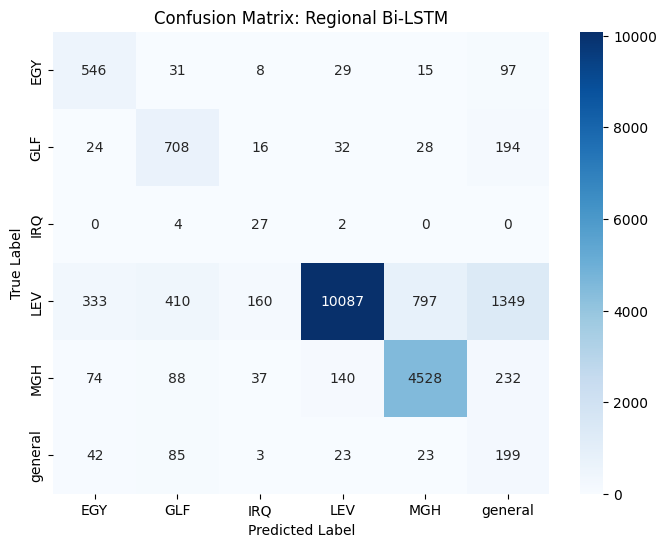

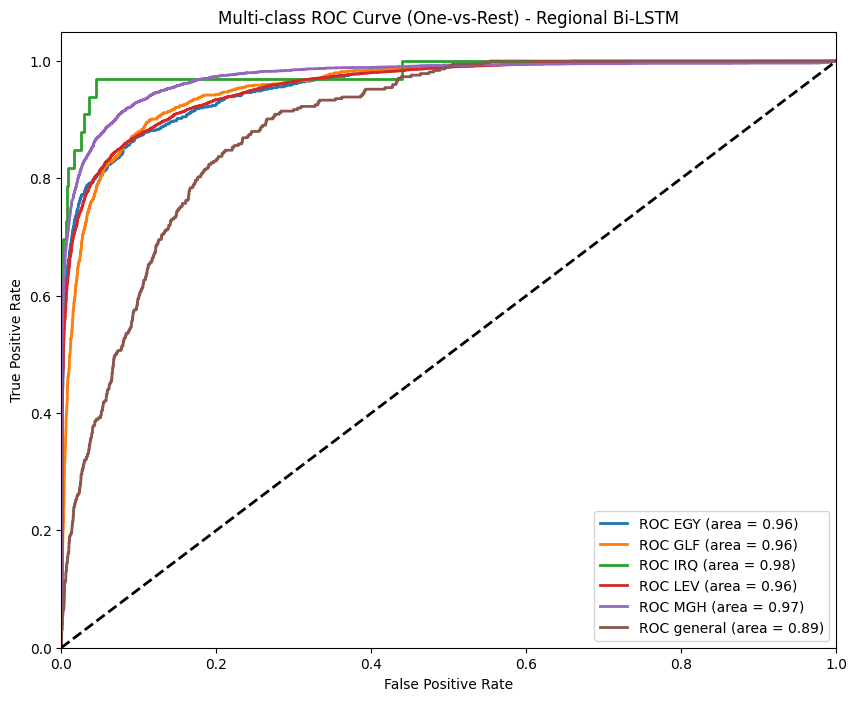


==================== Advanced Evaluation: Regional CNN ====================
637/637 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Accuracy: 0.8370
F1-Weighted: 0.8529
Matthews Correlation Coefficient (MCC): 0.7193

Classification Report:
              precision    recall  f1-score   support

         EGY       0.44      0.78      0.57       726
         GLF       0.48      0.71      0.57      1002
         IRQ       0.41      0.67      0.51        33
         LEV       0.96      0.84      0.90     13136
         MGH       0.87      0.90      0.88      5099
     general       0.15      0.32      0.21       375

    accuracy                           0.84     20371
   macro avg       0.55      0.70      0.61     20371
weighted avg       0.88      0.84      0.85     20371



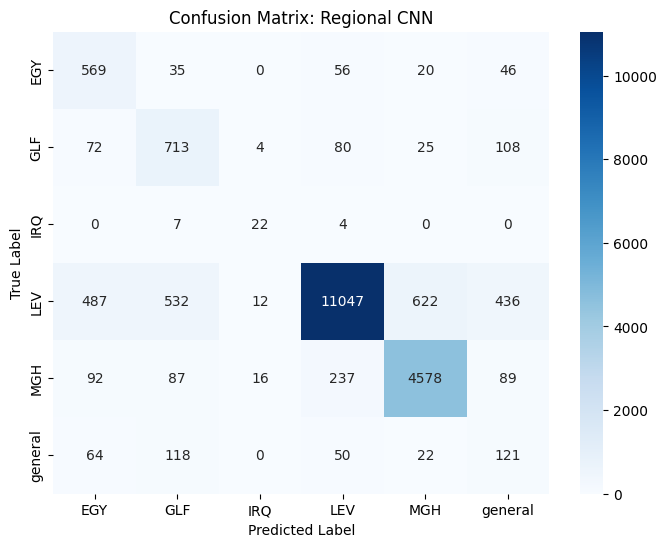

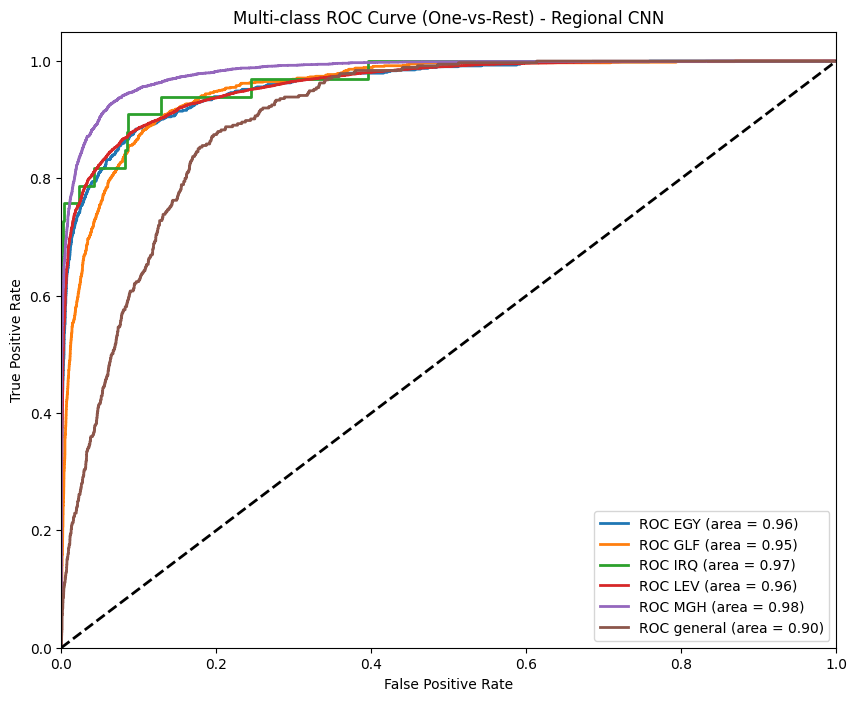


==================== Advanced Evaluation: Country Simple RNN ====================
637/637 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Accuracy: 0.4554
F1-Weighted: 0.4617
Matthews Correlation Coefficient (MCC): 0.3819

Classification Report:
              precision    recall  f1-score   support

     Algeria       0.43      0.68      0.53      2164
       Egypt       0.26      0.72      0.38       725
        Iraq       0.02      0.16      0.03        32
      Jordan       0.13      0.28      0.17      1053
     Lebanon       0.32      0.68      0.44      1625
     Morocco       0.45      0.44      0.44      1082
        GULF       0.60      0.14      0.23      2466
   Palestine       0.35      0.20      0.26      2679
       Syria       0.74      0.47      0.58      6746
     Tunisia       0.91      0.75      0.82      1799

    accuracy                           0.46     20371
   macro avg       0.42      0.45      0.39     20371
weighted avg       0.55      0.46      0.46     20371



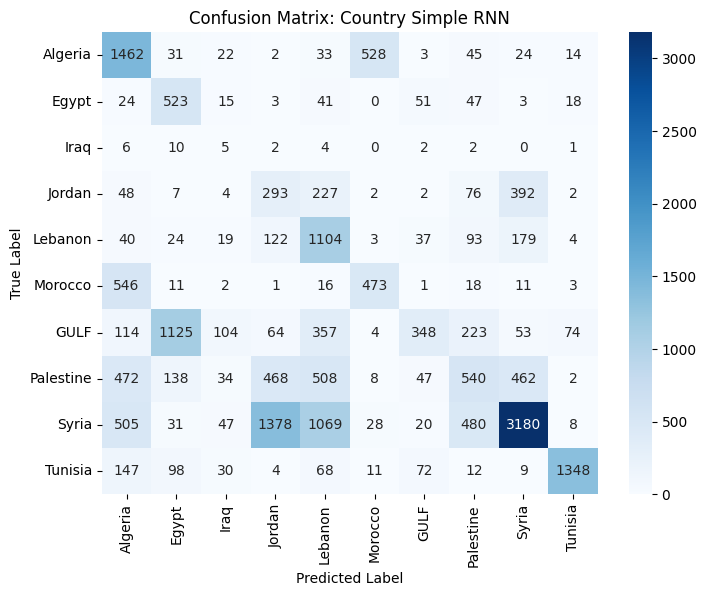

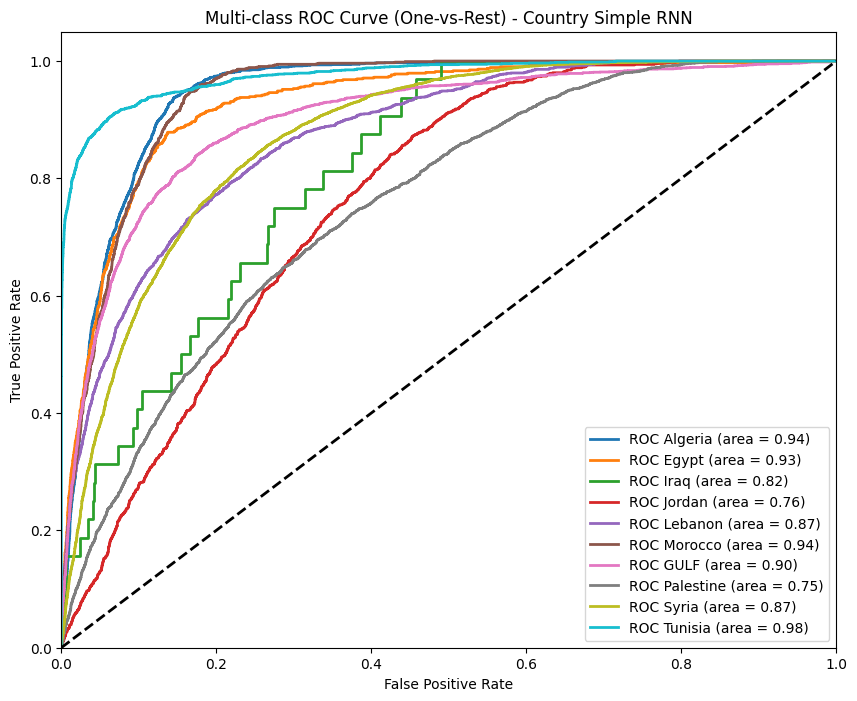


==================== Advanced Evaluation: Country Bi-LSTM ====================
637/637 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
Accuracy: 0.7781
F1-Weighted: 0.7821
Matthews Correlation Coefficient (MCC): 0.7369

Classification Report:
              precision    recall  f1-score   support

     Algeria       0.83      0.87      0.85      2164
       Egypt       0.61      0.75      0.67       725
        Iraq       0.43      0.62      0.51        32
      Jordan       0.53      0.63      0.58      1053
     Lebanon       0.62      0.80      0.70      1625
     Morocco       0.73      0.85      0.78      1082
        GULF       0.79      0.71      0.75      2466
   Palestine       0.65      0.67      0.66      2679
       Syria       0.92      0.79      0.85      6746
     Tunisia       0.92      0.92      0.92      1799

    accuracy                           0.78     20371
   macro avg       0.70      0.76      0.73     20371
weighted avg       0.79      0.78      0.78     20371



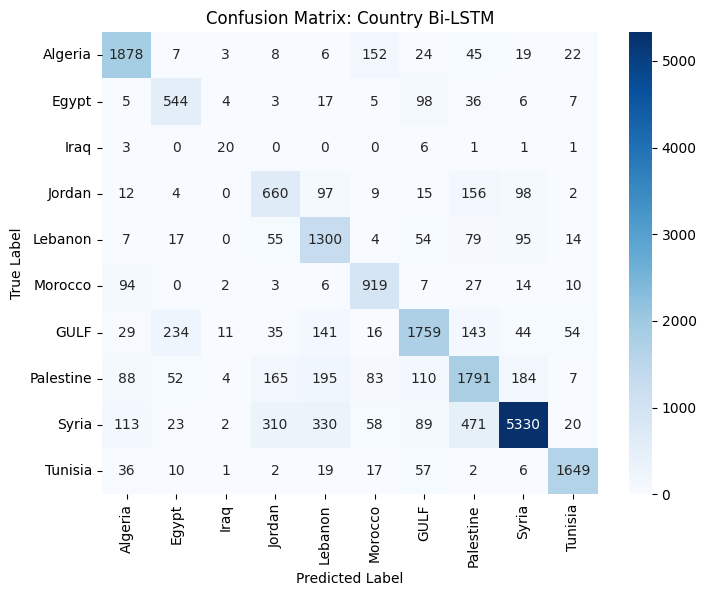

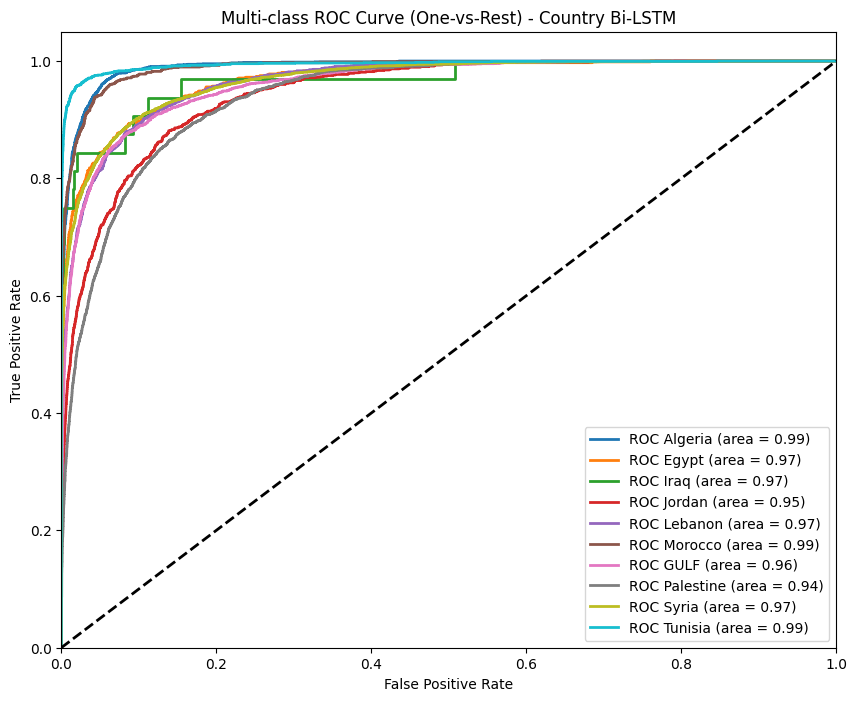


==================== Advanced Evaluation: Country CNN ====================
637/637 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy: 0.7672
F1-Weighted: 0.7699
Matthews Correlation Coefficient (MCC): 0.7226

Classification Report:
              precision    recall  f1-score   support

     Algeria       0.79      0.89      0.84      2164
       Egypt       0.70      0.63      0.67       725
        Iraq       0.52      0.50      0.51        32
      Jordan       0.56      0.55      0.55      1053
     Lebanon       0.61      0.74      0.67      1625
     Morocco       0.80      0.75      0.77      1082
        GULF       0.72      0.78      0.75      2466
   Palestine       0.61      0.67      0.63      2679
       Syria       0.91      0.79      0.84      6746
     Tunisia       0.91      0.90      0.91      1799

    accuracy                           0.77     20371
   macro avg       0.71      0.72      0.71     20371
weighted avg       0.78      0.77      0.77     20371



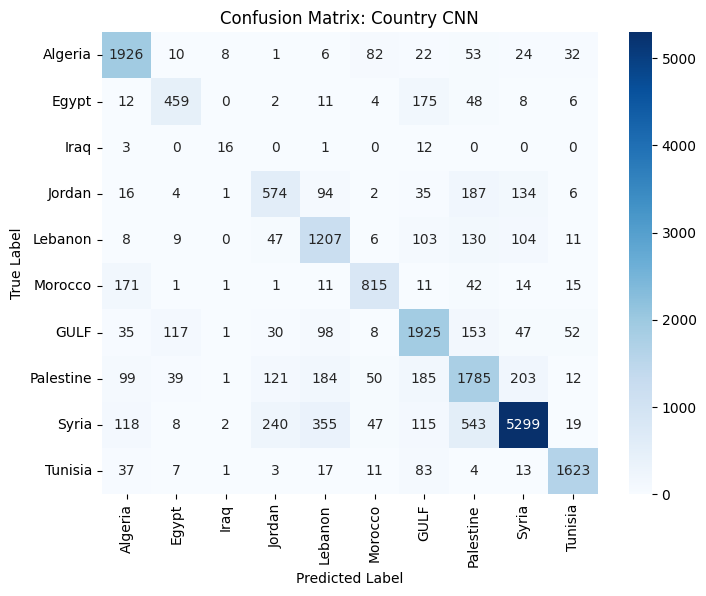

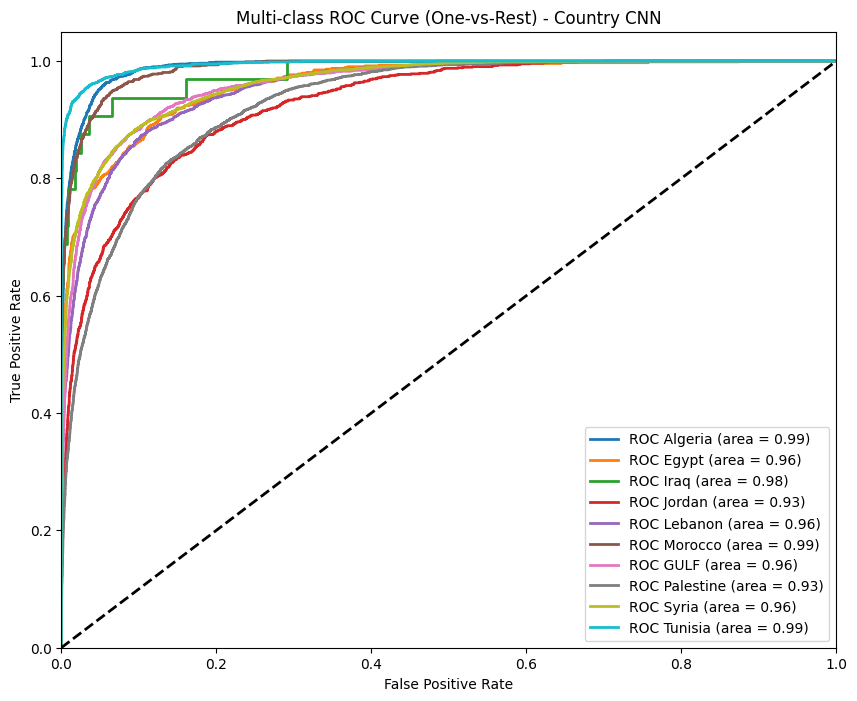

In [ ]:
results = []

# Regional Evaluations
results.append(evaluate_advanced_metrics(rnn_regional, X_test_k, y_test_k, label_list_k, "Regional Simple RNN"))
results.append(evaluate_advanced_metrics(lstm_regional, X_test_k, y_test_k, label_list_k, "Regional Bi-LSTM"))
results.append(evaluate_advanced_metrics(cnn_regional, X_test_k, y_test_k, label_list_k, "Regional CNN"))

# Country Evaluations
results.append(evaluate_advanced_metrics(rnn_country, X_test_c, y_test_c, display_country_list, "Country Simple RNN"))
results.append(evaluate_advanced_metrics(lstm_country, X_test_c, y_test_c, display_country_list, "Country Bi-LSTM"))
results.append(evaluate_advanced_metrics(cnn_country, X_test_c, y_test_c, display_country_list, "Country CNN"))



## 11. Final Summary


,Model,Accuracy,F1-Weighted,MCC
2,Regional CNN,0.836974,0.852915,0.719286
1,Regional Bi-LSTM,0.790094,0.826390,0.670027
4,Country Bi-LSTM,0.778067,0.782072,0.736929
5,Country CNN,0.767218,0.769942,0.722626
0,Regional Simple RNN,0.624270,0.683148,0.468998
3,Country Simple RNN,0.455353,0.461721,0.381885


/tmp/ipykernel_6986/2071795913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Weighted', y='Model', data=res_df.sort_values(by='F1-Weighted', ascending=False), palette='viridis')


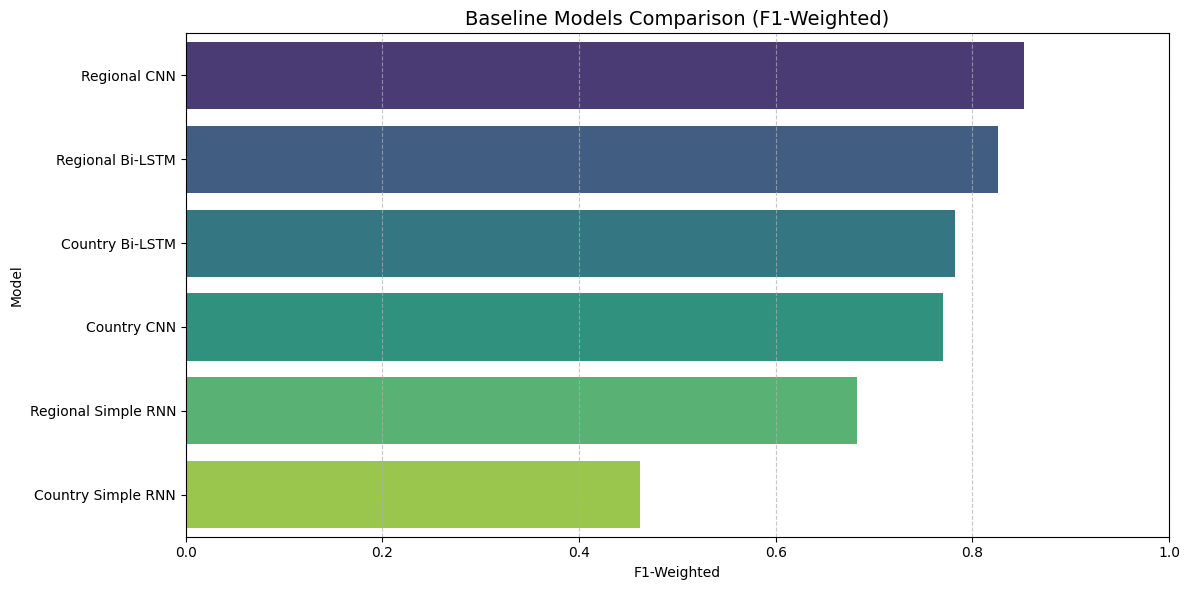

In [ ]:
res_df = pd.DataFrame(results)
display(res_df.sort_values(by=['F1-Weighted'], ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='F1-Weighted', y='Model', data=res_df.sort_values(by='F1-Weighted', ascending=False), palette='viridis')
plt.title('Baseline Models Comparison (F1-Weighted)', fontsize=14)
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

